In [1]:
!pip install torchaudio-augmentations
!pip install audio_augmentations
!pip install wandb --upgrade

import torch
import torchaudio
import torchtext
import torchaudio.functional as F
import torchaudio.transforms as T
from audio_augmentations import *

import os, re, random
import numpy as np
import sklearn
import itertools
import time

import pickle
from tqdm.auto import tqdm
from IPython.display import clear_output
import IPython.display as ipd
import gc
import matplotlib.pyplot as plt
import wandb

print(torch.__version__)
print(torchaudio.__version__)

import sys

# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:256"
sys.path.append('/kaggle/working/Voice-commands-recognition')
sys.path.append('/kaggle/working/Voice-commands-recognition/notebooks')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for julius: filename=julius-0.2.7-py3-none-any.whl size=21895 sha256=3c03b7e4fc9507de0681b7d563877b23149eb213320fb4b364297659099d304b
  Stored in directory: /root/.cache/pip/wheels/b9/b2/05/f883527ffcb7f2ead5438a2c23439aa0c881eaa9a4c80256f4
Successfully built julius
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.15.0
    Uninstalling wandb-0.15.0:
      Successfully uninstalled wandb-0.15.0


[   INFO   ] MusicExtractorSVM: no classifier models were configured by default
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


2.0.0
2.0.1


In [2]:
!rm -rf ./Voice-commands-recognition
!git clone https://github.com/litvan007/Voice-commands-recognition.git
!mkdir /kaggle/working/Voice-commands-recognition/notebooks/signal_plots
!mkdir /kaggle/working/Voice-commands-recognition/notebooks/spec_plots
!mkdir /kaggle/working/Voice-commands-recognition/notebooks/mfcc_plots
!mkdir /kaggle/working/Voice-commands-recognition/checkpoints
!ls ./Voice-commands-recognition

Cloning into 'Voice-commands-recognition'...
remote: Enumerating objects: 11255, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 11255 (delta 33), reused 61 (delta 23), pack-reused 11180
Receiving objects: 100% (11255/11255), 1.07 GiB | 28.34 MiB/s, done.
Resolving deltas: 100% (70/70), done.
mkdir: cannot create directory ‘/kaggle/working/Voice-commands-recognition/checkpoints’: File exists
README.md    configs  notebooks    pyproject.toml
checkpoints  models   poetry.lock  tests


In [3]:
random.seed(123456)
np.random.seed(123456)
torch.manual_seed(123456)

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

In [4]:
def create_plots(signal, feature_map, name_fig, sample_rate=16000, 
                            signal_plot_dir='signal_plots', 
                            spec_plot_dir='spec_plots', 
                            mfcc_plot_dir='mfcc_plots',
                            notebook_path='/kaggle/working/Voice-commands-recognition/notebooks'):
    
    signal = signal.numpy()

    num_frames = signal.size
    time_axis = torch.arange(0, num_frames) / sample_rate
    plt.plot(time_axis, signal, linewidth=1)
    plt.xlabel('Time')
    plt.title('Signal')
    plt.grid()
    plt.savefig(os.path.join(notebook_path, signal_plot_dir, name_fig))
    plt.clf()

    plt.specgram(signal, Fs=sample_rate)
    plt.xlabel('Time')
    plt.title('Spectrogram')
    plt.savefig(os.path.join(notebook_path, spec_plot_dir, name_fig))
    plt.clf()

    plt.imshow(feature_map, interpolation='nearest', origin='lower', aspect='auto')
    plt.xlabel('Frame')
    plt.title('MFCC')
    plt.savefig(os.path.join(notebook_path, mfcc_plot_dir, name_fig))
    plt.clf()
    

In [5]:
def plot_waveform(waveform, mfcc, sample_rate=16000, title="Waveform", xlim=None):
    waveform = waveform.numpy()

    num_frames = waveform.size
    time_axis = torch.arange(0, num_frames) / sample_rate

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
    ax1.plot(time_axis, waveform, linewidth=1)
    ax1.set_xlabel('Time')
    ax1.set_title('Signal')

    ax2.specgram(waveform, Fs=sample_rate)
    ax2.set_xlabel('Time')
    ax2.set_title('Spectrogram')

    ax3.imshow(mfcc, interpolation='nearest', origin='lower', aspect='auto')
    ax3.set_xlabel('Frame')
    ax3.set_title('MFCC')

    plt.suptitle(title)
    plt.show()
    
    ax1.grid(True)
    if xlim:
        ax1.set_xlim(xlim)
        
    fig.suptitle(title)
    plt.show()

# Getting data

In [6]:
!pip install gdown
!gdown --id 1yhD3dA8fmKncYaHmfbj4I0W640DLBeND

/opt/conda/lib/python3.10/site-packages/gdown/cli.py:126: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (uriginal): https://drive.google.com/uc?id=1yhD3dA8fmKncYaHmfbj4I0W640DLBeND
From (redirected): https://drive.google.com/uc?id=1yhD3dA8fmKncYaHmfbj4I0W640DLBeND&confirm=t&uuid=4fb1cf85-1a35-4460-b471-70fa779c5002
To: /kaggle/working/data.zip
100%|███████████████████████████████████████| 2.73G/2.73G [00:11<00:00, 237MB/s]


In [7]:
path_to_zip_file = "/kaggle/working/data.zip"
directory_to_extract_to = "./"

import zipfile
with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
    zip_ref.extractall(directory_to_extract_to)

In [8]:
data_path = '/kaggle/working/data'
data_list = []
with open(os.path.join(data_path, 'data_base_audio.pickle'), 'rb') as fh:
    data_list = pickle.load(fh)
    
len(data_list)

27456

In [9]:
all_labels = set()
for example in data_list:
    all_labels.add(example['label'])
token_to_idx = {x: idx for idx, x in enumerate(all_labels)}
all_labels

{'Domoj',
 "Dvigat'sja",
 'Najti',
 "Opustit'",
 "Ostanovit'sja",
 "Otkryt'",
 "Podnjat'",
 "Smenit'",
 "Sohranit'",
 'Start',
 'Stop',
 'Vlevo',
 'Vniz',
 'Vpravo',
 'Vverh',
 "Zagruzit'",
 "Zahvatit'",
 "Zakryt'"}

split 80:10:10

In [10]:
rus_classes = [
 'Домой',
 'Двигаться',
 'Найти',
 'Опустить',
 'Остановиться',
 'Открыть', 
 'Поднять',
 'Сменить',
 'Сохранить',
 'Старт',
 'Стоп',   
 'Влево',
 'Вниз',   
 'Вправо',
 'Вверх',  
 'Загрузить',
 'Захватить',   
 'Закрыть'
 ]

In [11]:
lengths_subsets = {'train': int(0.8 * len(data_list)), 'valid': round(0.1 * len(data_list)), 'test': round(0.1 * len(data_list))}
train_vaild_subset, test_subset = torch.utils.data.random_split(data_list, 
                                                                [lengths_subsets['train']+lengths_subsets['valid'], lengths_subsets['test']])
train_subset, valid_subset = torch.utils.data.random_split(train_vaild_subset, 
                                                                [lengths_subsets['train'], lengths_subsets['valid']])
lengths_subsets

{'train': 21964, 'valid': 2746, 'test': 2746}

# Creating dataset

In [12]:
class Sound_dataset_commands(torch.utils.data.Dataset):
    def __init__(self, rootdir, subset, transform=None):
        self.transform = transform
        self.rootdir = rootdir
        self.subset = subset
        self.n_subset = len(self.subset)
        self.token_to_idx = {x: idx for idx, x in enumerate(all_labels)}
        self.idx_to_token = {idx: x for idx, x in enumerate(all_labels)}

    def __getitem__(self, index):
        name, label = self.subset[index].values()
        signal, sample_rate = torchaudio.load(os.path.join(self.rootdir, name))
        signal = signal[0]

        if self.transform:
            feature_map = self.transform(signal)
#             signal = self.transform.transforms[0](signal)
        idx_label = self.token_to_idx[label]

        return feature_map, idx_label, signal, name, label

    def __len__(self):
        return len(self.subset)

In [13]:
# 30мс 10мс шаг
n_fft = 480
win_length = None
hop_length = 160
mfcc_transform = T.MFCC(
    sample_rate=16000,
    n_mfcc=32,
    melkwargs={
        "n_fft": n_fft,
        "n_mels": 64,
        "hop_length": hop_length
    },
)

transforms = [
    mfcc_transform
]
transform = Compose(transforms=transforms)
data_set = {
            'train': Sound_dataset_commands(rootdir=data_path, subset=train_subset, transform=transform),
            'valid': Sound_dataset_commands(rootdir=data_path, subset=valid_subset, transform=transform),
            'test': Sound_dataset_commands(rootdir=data_path, subset=test_subset, transform=transform)
        }
c = itertools.cycle(data_set['train'])

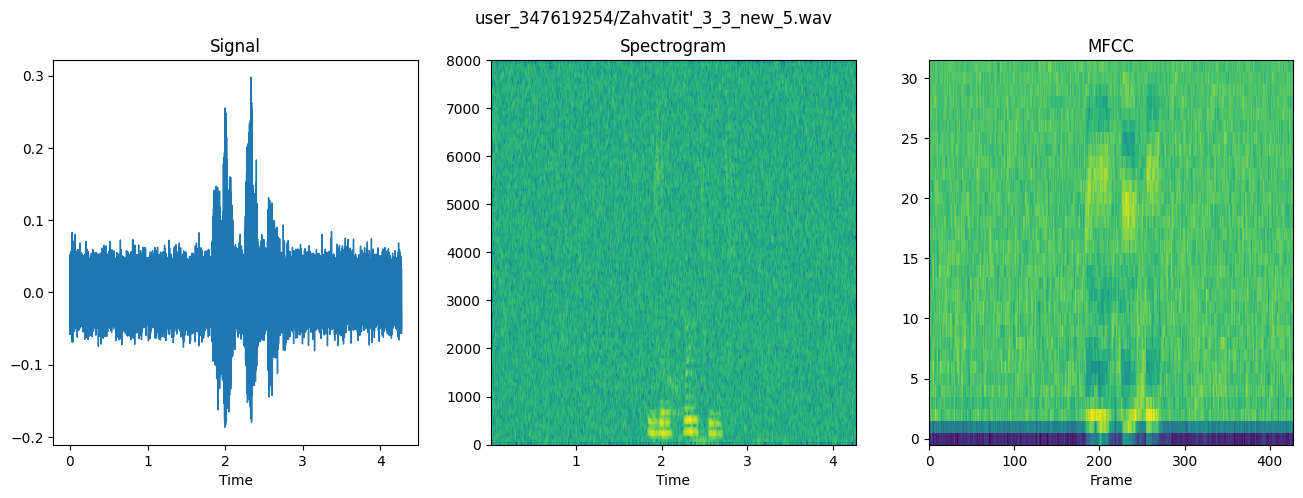

In [14]:
mfcc, label, signal, xname, label = next(c)
plot_waveform(signal, mfcc, sample_rate=16000, title=f'{xname}')
ipd.Audio(signal, rate=16000)

In [15]:
from models.model import Speech_recognition_model
import yaml

# Сделать разные конфиги
params = None
with open("/kaggle/working/Voice-commands-recognition/configs/model_params_res.yaml", "r") as stream:
    try:
        params = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

## Data Loader

In [16]:
def collate_fn(batch):
    X = torch.nn.utils.rnn.pad_sequence([sample[0].transpose(0, 1) for sample in batch], batch_first=True, padding_value=0).unsqueeze(1)
    y = torch.tensor([sample[1] for sample in batch])

    signal = [sample[2] for sample in batch]
    name = [sample[3] for sample in batch]
    label = [sample[4] for sample in batch]

    return X, y, signal, name, label

batch_size = params['Settings']['Other']['batch_size']
epochs = params['Settings']['Other']['epochs']
max_norm = params['Settings']['Optimizer_Scheduler']['max_norm']
loaders = {
        'train': torch.utils.data.DataLoader(data_set['train'], batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
        'valid': torch.utils.data.DataLoader(data_set['valid'], batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
        'test': torch.utils.data.DataLoader(data_set['test'], batch_size=1, shuffle=False, collate_fn=collate_fn)
        }

# Обучение и тестирование

## Wandb init

In [17]:
!wandb login --relogin a4fc0db907801a21173615cb84708e1774b986a4
wandb.init(project="Commands Recognition", name="main_training_final_3", config=params)
columns = ["name", "song_file", "signal_plot", "spec_plot", "mfcc_plot", "pred_label", "true_label"]
valid_table = wandb.Table(columns=columns)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


wandb: Currently logged in as: litvan. Use `wandb login --relogin` to force relogin


In [18]:
from models.model import Speech_recognition_model

def create_model_utils(params, weight_decay, amsgrad, max_lr, div_factor, epochs, steps_per_epoch, tl=False, tl_type='freeze', tl_low_lr=1e-8, load_path=None):
    tr_loss = []
    cv_loss = []
    tr_acc = []
    cv_acc = []
    epoch = 0
    model = Speech_recognition_model(**params).to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)

    optimizer = torch.optim.Adam(model.parameters(),
                                lr=max_lr/div_factor,
                                weight_decay=weight_decay,
                                amsgrad=amsgrad)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr,
                            steps_per_epoch=steps_per_epoch,
                            epochs=epochs, div_factor=div_factor)

    if tl:
        model.load_state_dict(torch.load('/kaggle/working/Voice-commands-recognition/checkpoints/sub_model_asr_2.pth', map_location=device), strict=False)
        if tl_type == 'freeze':
            for param in list(model.parameters())[:28]: #28
                param.requires_grad = False

        elif tl_type == 'low_step':
            optimizer = torch.optim.Adam(params=[
                                            {"params": list(model.parameters())[28:]},
                                            {"params": list(model.parameters())[:28], "lr": tl_low_lr}
                                        ], lr=max_lr/div_factor, weight_decay=weight_decay, amsgrad=amsgrad)

        elif tl_type == 'non_freeze':
            pass

    if load_path is not None:
        checkpoint = torch.load(load_path)

        model.load_state_dict(checkpoint['state_dict'], map_location=device)
        optimizer.load_state_dict(checkpoint['optim_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_dict'])
        tr_loss = checkpoint['tr_loss']
        cv_loss = checkpoint['cv_loss']
        epoch = checkpoint['epoch']
        tr_acc = checkpoint['tr_accuracy']
        cv_acc = checkpoint['cv_accuracy']
    
    return model, criterion, optimizer, scheduler, tr_loss, cv_loss, epoch, tr_acc, cv_acc

epochs = 100
model, criterion, optimizer, scheduler, tr_loss, cv_loss, epoch, tr_acc, cv_acc = create_model_utils(params['Architecture'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['weight_decay'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['amsgrad'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['max_lr'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['div_factor'],
                                                                                                    epochs,
                                                                                                    len(loaders['train']), tl=False)

In [19]:
def get_accuracy(y_pred, y_test):
    correct_results_sum = (y_pred == y_test).sum().float()
    acc = correct_results_sum/(y_test.size(0))
    
    return acc

In [20]:
from torchmetrics import  ConfusionMatrix
import seaborn as sn
import pandas as pd

signal_plot_dir='signal_plots'
spec_plot_dir='spec_plots'
mfcc_plot_dir='mfcc_plots'
notebook_path = '/kaggle/working/Voice-commands-recognition/notebooks'

confmat = ConfusionMatrix(task="multiclass", num_classes=18).to(device)

def run_one_epoch(epoch, cross_valid=False, print_freq=1):
    start = time.time()
    total_loss = 0
    total_accuracy = 0

    data_loader = loaders['train'] if not cross_valid else loaders['valid']

    for i, (data) in enumerate(tqdm(data_loader)):
        feature_map, idx_label, signal, name, label = data
        input_data = feature_map.to(device)
        target_labels = idx_label.to(device)

        output_logits = model(input_data)
        loss = criterion(output_logits, target_labels)
        if not cross_valid:
            optimizer.zero_grad()
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(),
                                                        max_norm)
            optimizer.step()

        total_loss += loss.item()
        pred_labels = torch.round(torch.sigmoid(output_logits)).type(torch.int8).argmax(1)
        accuracy = get_accuracy(pred_labels, target_labels)
        total_accuracy += accuracy
        optim_state = optimizer.state_dict()
        curr_lr = optim_state['param_groups'][0]['lr']

        if i % print_freq == 0:
                print('Epoch {0} | Iter {1} | Average Loss {2:.3f} | '
                    'Current Loss {3:.6f} | Current accuracy {4:.6f} | Current lr {5:.5f} | {6:.1f} ms/batch'.format(
                        epoch + 1, i + 1, total_loss / (i + 1),
                        loss.item(), accuracy, curr_lr, 1000 * (time.time() - start) / (i + 1)),
                    flush=True)

        if cross_valid:
            confmat.update(pred_labels, target_labels)            
            name_fig = f'{name[0].replace("/", "_").split(".")[0]}.png'
            create_plots(signal[0], feature_map[0][0], name_fig)    
            temp = [name[0], 
                wandb.Audio(signal[0], sample_rate=16000), 
                wandb.Image(os.path.join( notebook_path, signal_plot_dir, name_fig )),
                wandb.Image(os.path.join( notebook_path, spec_plot_dir, name_fig )),
                wandb.Image(os.path.join( notebook_path, mfcc_plot_dir, name_fig )),
                pred_labels[0],
                target_labels[0]]
            valid_table.add_row(*temp)
        torch.cuda.empty_cache()
        gc.collect()

    return total_loss / (i + 1), total_accuracy / (i + 1)

In [ ]:
checkpoint = False
visdom = True
save_folder = '/kaggle/working/'


best_val_loss = 10

wandb.watch(model, log_freq=1, log='all')
for epoch in tqdm(np.arange(epoch, epochs)):
    print("Training...")
    model.train()
    start = time.time()
    tr_avg_loss, tr_avg_acc = run_one_epoch(epoch)
    tr_loss.append(tr_avg_loss)
    tr_acc.append(tr_avg_acc)

    print('-' * 85)
    print('Train Summary | End of Epoch {0} | Time {1:.2f}s | '
                'Train Loss {2:.3f} | Accuracy {3:.3f}'.format(
                    epoch + 1, time.time() - start, tr_avg_loss, tr_avg_acc))
    print('-' * 85)

    if checkpoint:
        file_path = os.path.join(
        save_folder, 'epoch_{0}_loss_{1:.4f}.pth.tar'.format(epoch + 1, cv_avg_loss))
        torch.save(model.serialize(model, optimizer, scheduler, epoch + 1,
                                        tr_loss=tr_loss,
                                        cv_loss=cv_loss),
                file_path)
        print('Saving checkpoint model to %s' % file_path)

    print('Cross validation...')
    model.eval()  # Turn off Batchnorm & Dropout
    cv_avg_loss, cv_avg_acc = run_one_epoch(epoch, cross_valid=True)
    cv_loss.append(cv_avg_loss)
    cv_acc.append(cv_avg_acc)
    
    # Confusion matrix
    temp_matrix = confmat.compute()
    df_cm = pd.DataFrame(temp_matrix.cpu().numpy() , index = [i for i in rus_classes], columns = [i for i in rus_classes])

    print('Num of val samples: {}. Check this aligns with the numbers from the dataloader'.format(df_cm.sum(axis=1).sum()))
    # df_cm.to_csv('raw_nums.csv') # you can use this to validate the number of samples is correct
    #normalise the confusion matrix 
    norm =  np.sum(df_cm, axis=1)
    normalized_cm = (df_cm.T/norm).T # 
    #validate the confusion matrix sums to num of classes
    if normalized_cm.sum(axis=1).sum() != 18:
        print('Error with confusion matrix')
        sys.exit() 

    normalized_cm.to_csv('normalized_cm.csv')
    f, ax = plt.subplots(figsize = (15,10)) 
    sn.heatmap(normalized_cm, annot=True, ax=ax)

    print('-' * 185)
    print('Valid Summary | End of Epoch {0} | Time {1:.2f}s | '
            'Valid Loss {2:.3f} | Accuracy {3:.3f}'.format(
                epoch + 1, time.time() - start, cv_avg_loss, cv_avg_acc))
    print('-' * 185)

    # Save the best model
    if cv_avg_loss < best_val_loss:
        best_val_loss = cv_avg_loss
        model_path = 'epoch_{0}_loss_{1:.4f}_best.pth.tar'.format(epoch + 1, cv_avg_loss)
        file_path = os.path.join(save_folder, model_path)
        torch.save(model.serialize(model, optimizer, scheduler, epoch + 1,
                                    tr_losses=tr_loss,
                                    cv_losses=cv_loss,
                                    tr_accuracy=tr_acc,
                                    cv_accuracy=cv_acc),
                file_path)
        print("Find better validated model, saving to %s" % file_path)


    wandb.log({"epoch": epoch})
    wandb.log({"train_loss": tr_avg_loss})
    wandb.log({"valid_loss": cv_avg_loss})
    wandb.log({"train_accuracy": tr_avg_acc})
    wandb.log({"valid_accuracy": cv_avg_acc})
    wandb.log({"Confusion martix": wandb.Image(f)})
    wandb.run.log({"valid_inference" : valid_table}) 
    confmat.reset()

  0%|          | 0/100 [00:00<?, ?it/s]

Training...


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 1 | Iter 1 | Average Loss 3.033 | Current Loss 3.032534 | Current accuracy 0.000000 | Current lr 0.00056 | 5954.5 ms/batch
Epoch 1 | Iter 2 | Average Loss 3.064 | Current Loss 3.094957 | Current accuracy 0.046875 | Current lr 0.00056 | 3987.9 ms/batch
Epoch 1 | Iter 3 | Average Loss 3.005 | Current Loss 2.888562 | Current accuracy 0.046875 | Current lr 0.00056 | 3314.1 ms/batch
Epoch 1 | Iter 4 | Average Loss 2.990 | Current Loss 2.943016 | Current accuracy 0.015625 | Current lr 0.00056 | 2985.0 ms/batch
Epoch 1 | Iter 5 | Average Loss 2.968 | Current Loss 2.881887 | Current accuracy 0.062500 | Current lr 0.00056 | 2796.9 ms/batch
Epoch 1 | Iter 6 | Average Loss 2.954 | Current Loss 2.880817 | Current accuracy 0.031250 | Current lr 0.00056 | 2622.6 ms/batch
Epoch 1 | Iter 7 | Average Loss 2.948 | Current Loss 2.914596 | Current accuracy 0.062500 | Current lr 0.00056 | 2604.4 ms/batch
Epoch 1 | Iter 8 | Average Loss 2.948 | Current Loss 2.947692 | Current accuracy 0.062500 | Curre

  0%|          | 0/43 [00:00<?, ?it/s]

...

Epoch 5 | Iter 1 | Average Loss 0.859 | Current Loss 0.859420 | Current accuracy 0.125000 | Current lr 0.00056 | 1465.4 ms/batch
Epoch 5 | Iter 2 | Average Loss 0.779 | Current Loss 0.699327 | Current accuracy 0.125000 | Current lr 0.00056 | 1682.4 ms/batch
Epoch 5 | Iter 3 | Average Loss 0.737 | Current Loss 0.651909 | Current accuracy 0.140625 | Current lr 0.00056 | 1730.9 ms/batch
Epoch 5 | Iter 4 | Average Loss 0.678 | Current Loss 0.500462 | Current accuracy 0.125000 | Current lr 0.00056 | 1750.4 ms/batch
Epoch 5 | Iter 5 | Average Loss 0.617 | Current Loss 0.374118 | Current accuracy 0.140625 | Current lr 0.00056 | 1754.6 ms/batch
Epoch 5 | Iter 6 | Average Loss 0.639 | Current Loss 0.746919 | Current accuracy 0.140625 | Current lr 0.00056 | 1712.2 ms/batch
Epoch 5 | Iter 7 | Average Loss 0.599 | Current Loss 0.361020 | Current accuracy 0.109375 | Current lr 0.00056 | 1732.0 ms/batch
Epoch 5 | Iter 8 | Average Loss 0.584 | Current Loss 0.482175 | Current accuracy 0.140625 | Curre

  0%|          | 0/43 [00:00<?, ?it/s]

Epoch 5 | Iter 1 | Average Loss 0.346 | Current Loss 0.346048 | Current accuracy 0.125000 | Current lr 0.00056 | 621.4 ms/batch


/opt/conda/lib/python3.10/site-packages/matplotlib/axes/_axes.py:7726: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


Epoch 5 | Iter 2 | Average Loss 0.354 | Current Loss 0.362075 | Current accuracy 0.156250 | Current lr 0.00056 | 1560.8 ms/batch
Epoch 5 | Iter 3 | Average Loss 0.345 | Current Loss 0.326107 | Current accuracy 0.156250 | Current lr 0.00056 | 1806.5 ms/batch
Epoch 5 | Iter 4 | Average Loss 0.342 | Current Loss 0.335139 | Current accuracy 0.125000 | Current lr 0.00056 | 1977.3 ms/batch
Epoch 5 | Iter 5 | Average Loss 0.350 | Current Loss 0.381037 | Current accuracy 0.109375 | Current lr 0.00056 | 2060.1 ms/batch
Epoch 5 | Iter 6 | Average Loss 0.358 | Current Loss 0.394646 | Current accuracy 0.156250 | Current lr 0.00056 | 2070.9 ms/batch
Epoch 5 | Iter 7 | Average Loss 0.375 | Current Loss 0.477074 | Current accuracy 0.171875 | Current lr 0.00056 | 2073.6 ms/batch
Epoch 5 | Iter 8 | Average Loss 0.382 | Current Loss 0.434302 | Current accuracy 0.203125 | Current lr 0.00056 | 2105.5 ms/batch
Epoch 5 | Iter 9 | Average Loss 0.402 | Current Loss 0.562464 | Current accuracy 0.218750 | Curre